# 06 - TF-IDF + LinearSVC

SVM linear, historicamente forte em classificacao de texto esparso de alta dimensionalidade.

**Entrada:** `data/processed/{train,val,test}.parquet`
**Saidas:** `models/tfidf_linear_svc/model.pkl`, `metrics.json`, `search_log.csv`

> Este notebook tem a **mesma estrutura** dos demais notebooks de modelo. So muda o
> estimador. Isso e proposital: mantem a comparacao justa e o codigo previsivel.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import ensure_dirs, load_config, set_seed

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

SEED = set_seed()
CONFIG = load_config()
ensure_dirs()
print(f"seed={SEED} | classes={CONFIG['classes']}")

seed=42 | classes=['normal', 'atencao', 'urgente']


## 1. Busca de hiperparametros

A selecao acontece na **validacao**. O split de teste nao e tocado aqui.

In [2]:
from src.models.pipelines import param_grid

CANDIDATO = "tfidf_linear_svc"
grade = param_grid(CANDIDATO)
print(f"Combinacoes a avaliar: {len(grade)}")
for params in grade:
    print(" ", params)

Combinacoes a avaliar: 3
  {'C': 0.5, 'class_weight': 'balanced'}
  {'C': 1.0, 'class_weight': 'balanced'}
  {'C': 3.0, 'class_weight': 'balanced'}


## 2. Treino, avaliacao e latencia

`run_candidate` executa a busca, treina o modelo final, avalia em validacao e teste, mede latencia pelo protocolo unico e persiste os artefatos.

In [3]:
from src.models.experiment import run_candidate

resultado = run_candidate(CANDIDATO)
print("Melhores parametros:", resultado["best_params"])

Melhores parametros: {'C': 0.5, 'class_weight': 'balanced'}


### Log da busca

In [4]:
display(resultado["search_log"].head(10))

,params,f1_macro,f1_weighted,accuracy,recall_normal,precision_normal,recall_atencao,precision_atencao,recall_urgente,precision_urgente
0,"{""C"": 0.5, ""class_weight"": ""balanced""}",0.751065,0.745973,0.746437,0.702586,0.734234,0.765854,0.753600,0.796247,0.755725
1,"{""C"": 1.0, ""class_weight"": ""balanced""}",0.746898,0.741289,0.741686,0.698276,0.725373,0.764228,0.746032,0.785523,0.763021
2,"{""C"": 3.0, ""class_weight"": ""balanced""}",0.728008,0.722632,0.722684,0.692529,0.699565,0.739837,0.726837,0.750670,0.758808


## 3. Metricas

In [5]:
comparativo = pd.DataFrame({
    "validacao": resultado["val_metrics"],
    "teste": resultado["test_metrics"],
}).round(4)
display(comparativo)

,validacao,teste
f1_macro,0.7511,0.7582
f1_weighted,0.7460,0.7544
accuracy,0.7464,0.7549
recall_normal,0.7026,0.7116
precision_normal,0.7342,0.7470
recall_atencao,0.7659,0.7695
precision_atencao,0.7536,0.7732
recall_urgente,0.7962,0.8118
precision_urgente,0.7557,0.7402


> Uma queda grande de validacao para teste indica overfitting na busca de hiperparametros.

In [6]:
from src.data.loader import load_split
from src.evaluation.metrics import confusion, report

teste = load_split("test")
print(report(teste["urgencia"], resultado["test_pred"]))

              precision    recall  f1-score   support

      normal       0.75      0.71      0.73       697
     atencao       0.77      0.77      0.77       616
     urgente       0.74      0.81      0.77       372

    accuracy                           0.75      1685
   macro avg       0.75      0.76      0.76      1685
weighted avg       0.76      0.75      0.75      1685



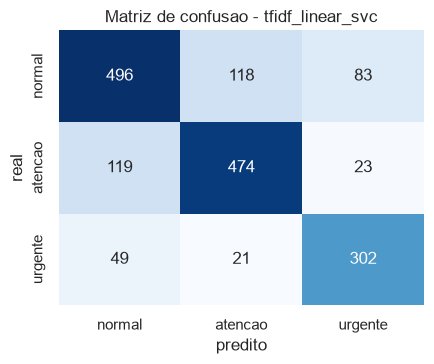

'urgente' classificado como 'normal': 49 de 372


In [7]:
matriz = confusion(teste["urgencia"], resultado["test_pred"])
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_title(f"Matriz de confusao - {CANDIDATO}")
plt.tight_layout()
plt.show()

erro_critico = matriz.loc["urgente", "normal"]
total_urgente = matriz.loc["urgente"].sum()
print(f"'urgente' classificado como 'normal': {erro_critico} de {total_urgente}")

> `urgente` predito como `normal` e o erro clinicamente caro. Um modelo com F1-macro alto e essa celula alta nao serve.

## 4. Latencia

In [8]:
latencia = pd.Series(resultado["latency"]).round(3).to_frame("ms")
display(latencia)

teto = CONFIG["promotion"]["max_latency_p95_ms"]
p95 = resultado["latency"]["latency_p95_ms"]
print(f"p95={p95:.2f}ms | teto={teto}ms | {'DENTRO' if p95 <= teto else 'ACIMA'}")

,ms
latency_p50_ms,1.454
latency_p95_ms,3.144
latency_p99_ms,3.920
latency_mean_ms,1.682
latency_n_calls,1000.000


p95=3.14ms | teto=15.0ms | DENTRO


---

## Notas

_Nota: `LinearSVC` nao expoe `predict_proba`. Se a API precisar retornar score de confianca, sera necessario calibrar (`CalibratedClassifierCV`) ou usar `decision_function`. Registrar a decisao aqui._